
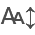

In [15]:
import pandas as pd
import os

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from itables import init_notebook_mode
init_notebook_mode(all_interactive=True)


In [9]:
extracted_data_input_path = os.path.join(os.getcwd(), '..', 'data', 'data_extracted')
merged_data_input_path = os.path.join(os.getcwd(), '..', 'data', 'data_merged')
processed_data_input_path = os.path.join(os.getcwd(), '..', 'data', 'data_processed')

In [4]:
stadiums = pd.read_csv(os.path.join(extracted_data_input_path, 'stadiums_location.csv'))
stadiums = stadiums[stadiums.index != 31]
stadiums

,team,stadium,latitude,longitude
0,Arsenal,Emirates Stadium,51.555040,-0.108400
1,Aston Villa,Villa Park,52.509126,-1.885035
2,Bournemouth,Vitality Stadium,50.735181,-1.838328
3,Brentford,Gtech Community Stadium,51.490713,-0.288980
4,Brighton,American Express Community Stadium,50.861547,-0.083693
5,Burnley,Turf Moor,53.789361,-2.229855
6,Cardiff,Cardiff City Stadium,51.472821,-3.202963
7,Chelsea,Stamford Bridge,51.481687,-0.191034
8,Crystal Palace,Selhurst Park,51.398243,-0.085255
9,Everton,Goodison Park,53.438690,-2.966419


In [53]:
import xyzservices.providers as xyz

In [67]:
import folium

# Example point coordinates


# Center map on first point
m = folium.Map(location=[stadiums.loc[0,'latitude'], stadiums.loc[0, 'longitude']], zoom_start=7.5,
                   tiles='https://{s}.basemaps.cartocdn.com/rastertiles/voyager_nolabels/{z}/{x}/{y}{r}.png', 
	attr= '&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a> contributors &copy; <a href="https://carto.com/attributions">CARTO</a>',
	subdomains= 'abcd',
	maxZoom= 20)

# Add points
for idx, st in stadiums.iterrows():
    add_long = 0
    add_lat = 0.05
    if st['team'] in ['Liverpool', 'West Brom', 'Manchester United']:
        add_long = 0.05
        add_lat = -0.03
    if st['team'] in ['Fulham', 'Tottenham Old']:
        add_lat = -0.09
        add_long = 0.02
    if st['team'] in ['Arsenal']:
        add_long = -0.02
    if st['team'] in ['Brentford']:
        add_lat = -0.2

    
    folium.CircleMarker(
        location=[st['latitude'], st['longitude']],
        radius=4,
        color='blue',
        fill=True,
        fill_color='blue',
        tooltip=st['team']
    ).add_to(m)
    folium.map.Marker(
        location=[st['latitude'] - add_long, st['longitude']+add_lat],
        icon=folium.DivIcon(
            html=f"""<div style="font-size: 20px; color: black; white-space: nowrap;">{st['team']}</div>"""
        )
    ).add_to(m)


# Show map (in Jupyter, or save to HTML)
m.save('map.html')
m  # if you're in Jupyter Notebook

In [5]:
merged_data = pd.read_csv(os.path.join(merged_data_input_path, 'merged_data.csv'))
merged_data

,season,gameweek,dayofweek,datetime,team,opponent,home_game,xG,xGA,possesion,...,surface_pressure,wind_speed_10m,relative_humidity_2m,wind_gusts_10m,cloud_cover,et0_fao_evapotranspiration,stadium_team,stadium,latitude,longitude
0,2017/2018,1,Fri,2017-08-11 19:45:00+01:00,Arsenal,Leicester,1,2.5,1.5,68,...,1010.681500,18.374111,79.259220,33.839996,24.0,0.054559,Arsenal,Emirates Stadium,51.555040,-0.108400
1,2017/2018,1,Fri,2017-08-11 19:45:00+01:00,Leicester,Arsenal,0,1.5,2.5,32,...,1010.681500,18.374111,79.259220,33.839996,24.0,0.054559,Arsenal,Emirates Stadium,51.555040,-0.108400
2,2017/2018,1,Sat,2017-08-12 12:30:00+01:00,Watford,Liverpool,1,2.1,2.6,46,...,1007.010437,17.654688,60.304508,38.160000,100.0,0.312157,Watford,Vicarage Road Stadium,51.649759,-0.401349
3,2017/2018,1,Sat,2017-08-12 12:30:00+01:00,Liverpool,Watford,0,2.6,2.1,54,...,1007.010437,17.654688,60.304508,38.160000,100.0,0.312157,Watford,Vicarage Road Stadium,51.649759,-0.401349
4,2017/2018,1,Sat,2017-08-12 15:00:00+01:00,Everton,Stoke,1,0.6,0.4,60,...,1011.095300,24.798225,70.116760,48.239998,73.0,0.242363,Everton,Goodison Park,53.438690,-2.966419
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6075,2024/2025,38,Sun,2025-05-25 16:00:00+01:00,Everton,Newcastle,0,1.2,1.2,35,...,995.349500,28.915081,60.904438,66.240000,31.0,0.262549,Newcastle,St James' Park,54.975469,-1.621874
6076,2024/2025,38,Sun,2025-05-25 16:00:00+01:00,Bournemouth,Leicester,1,1.6,0.3,63,...,1009.314330,24.491909,44.757860,56.160000,43.0,0.258621,Bournemouth,Vitality Stadium,50.735181,-1.838328
6077,2024/2025,38,Sun,2025-05-25 16:00:00+01:00,Leicester,Bournemouth,0,0.3,1.6,37,...,1009.314330,24.491909,44.757860,56.160000,43.0,0.258621,Bournemouth,Vitality Stadium,50.735181,-1.838328
6078,2024/2025,38,Sun,2025-05-25 16:00:00+01:00,Tottenham,Brighton,1,2.0,2.2,34,...,1008.944397,22.245117,40.724518,50.759998,91.0,0.322955,Tottenham,Tottenham Hotspur Stadium,51.604157,-0.066260


In [8]:
pd.DataFrame(data={'Wartości Brakujące (malejąco)': merged_data.isna().sum().sort_values(ascending=False)}).head(10)

,Wartości Brakujące (malejąco)
comp_before_name,4652
comp_before_date,4652
comp_after_date,4651
comp_after_name,4651
shots_allowed,0
draw_odds,0
win_odds,0
red_cards_opponent,0
red_cards,0
season,0


In [10]:
df_features = pd.read_csv(os.path.join(processed_data_input_path, 'features_added.csv'))

In [13]:
df_features

Loading ITables v2.4.0 from the init_notebook_mode cell... (need help?)


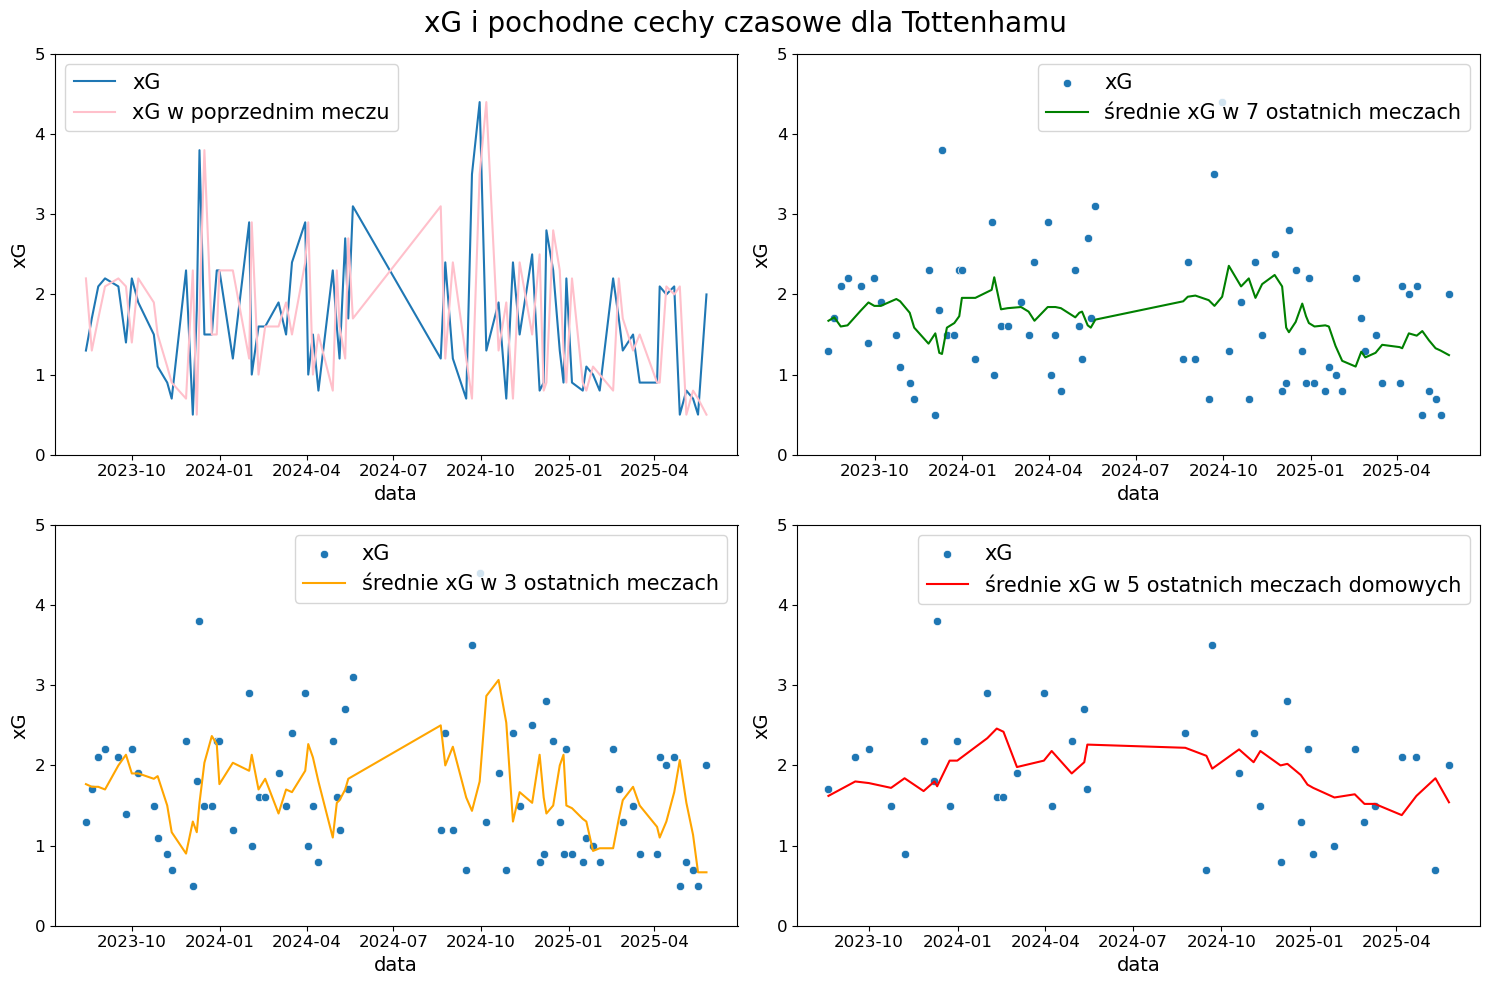

In [98]:

df_tott = df_features[(df_features['team'] == 'Tottenham') & (df_features['datetime'] > '2023-07-01')]
df_tott.loc[:, 'datetime'] = pd.to_datetime(df_tott['datetime'], utc=True).dt.tz_localize(None)


xticks = pd.date_range('2024-01-01', '2025-01-01', freq='12MS')  # "12MS" = month start, yearly

fig, ax = plt.subplots(2,2, figsize=(15, 10))

ax = ax.flatten()

sns.lineplot(data=df_tott, x='datetime', y='xG', ax=ax[0], label='xG')
sns.lineplot(data=df_tott, x='datetime', y='last_1_xG', ax=ax[0], color='pink', label='xG w poprzednim meczu')
# Plot multiple lines (Seaborn handles grouping by 'hue')


sns.scatterplot(data=df_tott, x='datetime', y='xG', ax=ax[1], marker='o', label='xG')
sns.lineplot(data=df_tott, x='datetime', y='avg_7_xG', color='green', ax=ax[1], label='średnie xG w 7 ostatnich meczach')

sns.scatterplot(data=df_tott, x='datetime', y='xG', ax=ax[2], marker='o', label='xG')
sns.lineplot(data=df_tott, x='datetime', y='avg_3_xG', color='orange', ax=ax[2], label='średnie xG w 3 ostatnich meczach')

sns.scatterplot(data=df_tott[df_tott['home_game'] == 1], x='datetime', y='xG', ax=ax[3], marker='o', label='xG')
sns.lineplot(data=df_tott[df_tott['home_game'] == 1], x='datetime', y='avg_5_h/a_xG', color='red', ax=ax[3], label='średnie xG w 5 ostatnich meczach domowych')

for axis in ax:
    axis.set_ylim([0,5])
    axis.set_xlabel('data', fontsize=14)
    axis.set_ylabel("xG", fontsize=14)
    axis.legend(fontsize=15)
    axis.tick_params(axis='x', labelsize=12)  # X-axis ticks
    axis.tick_params(axis='y', labelsize=12) 
    


xticks = [d for d in xticks if d.month == 1 and d.day == 1]


fig.suptitle("xG i pochodne cechy czasowe dla Tottenhamu", fontsize=20)
plt.legend(fontsize=15)
plt.tight_layout()
plt.show()

In [84]:
import matplotlib.dates as mdates
df_tott = df_features[(df_features['team'] == 'Tottenham') & (df_features['datetime'] > '2023-07-01')]
df_tott.loc[:, 'datetime'] = pd.to_datetime(df_tott['datetime'], utc=True).dt.tz_localize(None)


xticks = pd.date_range('2024-01-01', '2025-01-01', freq='12MS')  # "12MS" = month start, yearly

ax.set_xticks(xticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
fig.suptitle("Trigonometric Functions", fontsize=16)

fig, ax = plt.subplots( figsize=(20, 10))


xticks = [d for d in xticks if d.month == 1 and d.day == 1]


plt.legend()
plt.show()

AttributeError: 'numpy.ndarray' object has no attribute 'set_xticks'

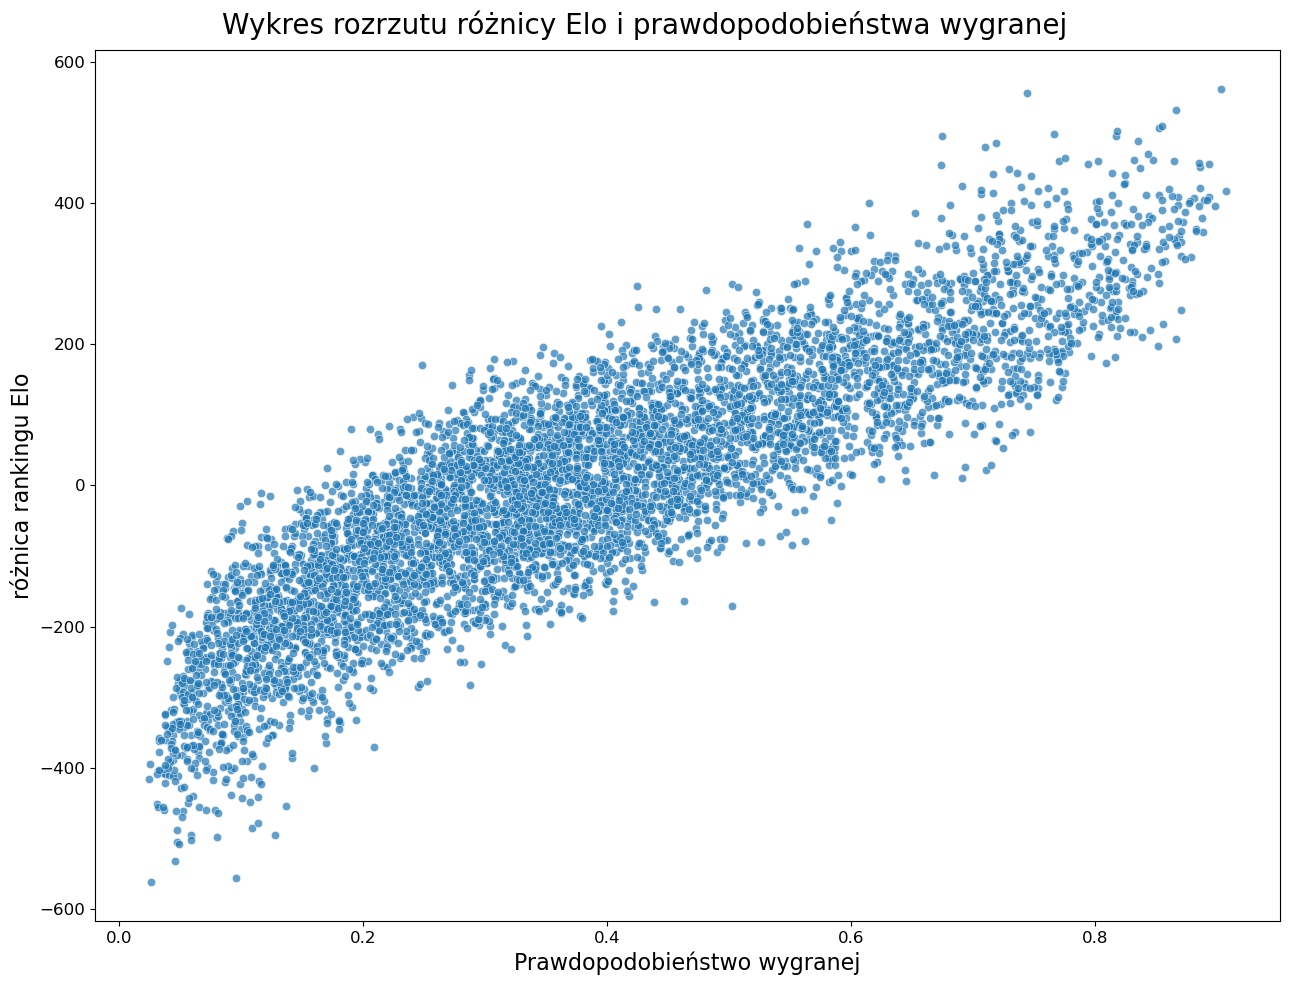

In [120]:

fig, ax = plt.subplots(figsize=(13, 10))


sns.scatterplot( x=df_features['win_probability'], y=df_features['elo'] - df_features['elo_opponent'], ax=ax, alpha=0.7)


ax.set_ylabel('różnica rankingu Elo', fontsize=16)
ax.set_xlabel('Prawdopodobieństwo wygranej', fontsize=16)
ax.tick_params(axis='x', labelsize=12)  # X-axis ticks
ax.tick_params(axis='y', labelsize=12) 

fig.suptitle("Wykres rozrzutu różnicy Elo i prawdopodobieństwa wygranej", fontsize=20)
plt.tight_layout()
plt.show()

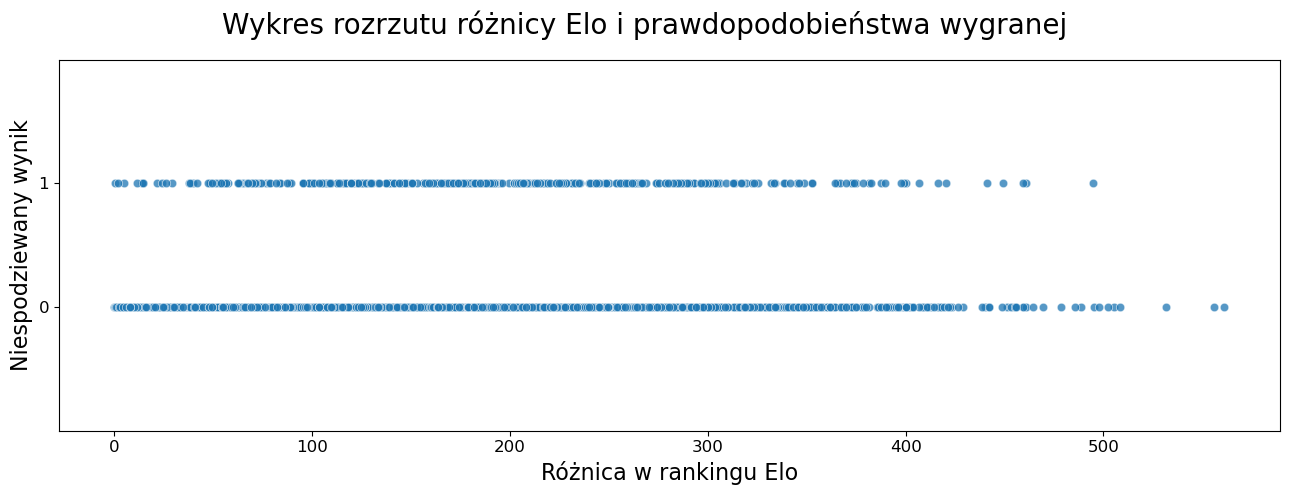

In [124]:
fig, ax = plt.subplots(figsize=(13, 5))


sns.scatterplot( x=df_features['elo_diff'], y=df_features['prob_unexpected_result'], ax=ax, alpha=0.5)


ax.set_ylabel('Niespodziewany wynik', fontsize=16)
ax.set_xlabel('Różnica w rankingu Elo', fontsize=16)
ax.tick_params(axis='x', labelsize=12)  # X-axis ticks
ax.tick_params(axis='y', labelsize=12) 
ax.set_yticks([0,1])
ax.set_ylim([-1,2])

fig.suptitle("Wykres rozrzutu różnicy Elo i prawdopodobieństwa wygranej", fontsize=20)
plt.tight_layout()
plt.show()

In [ ]:
def mann_whitney_test(df, variable, target='prob_unexpected_result'):
    group1 = df[df[target] == 1][variable]
    group2 = df[df[target] == 0][variable]
    
    if group1.empty or group2.empty:
        return [variable, None, None]
    
    u_statistic, p_value = mannwhitneyu(group1, group2, alternative='two-sided', nan_policy='omit')
    
    return [variable, p_value, u_statistic]
    
umannwhittney_df = pd.DataFrame(columns=['variable', 'p_value_mannwhit', 'u_statistic'])


for col in cont_cols:
    result = mann_whitney_test(df, col)
    umannwhittney_df.loc[len(umannwhittney_df)] = result
    
umannwhittney_df = umannwhittney_df.sort_values(by='p_value_mannwhit', ascending=False).reset_index(drop=True)
# umannwhittney_df['p_value_form'] = umannwhittney_df['p_value'].apply(lambda x: f"{x:.10f}")
umannwhittney_df
